<a href="https://colab.research.google.com/github/palahb/no2-prediction/blob/main/final_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatiotemporal NO2 Prediction using A3T-GCN
## Final Report - Extended Analysis

**Course:** CMP712 - Machine Learning  
**Student:** Halil Burak Pala  
**Institution:** Hacettepe University, Department of Computer Engineering

---

This notebook extends Progress Report 2 with the following analyses:

1. **Fixing A3T-GCN training** - lower learning rate, weight decay, dropout to address overfitting
2. **Hyperparameter sweep** - 3 configurations of A3T-GCN to find the best setup
3. **Ablation study** - comparing distance-based edge weights vs uniform edge weights
4. **Per-station error analysis** - identifying which stations are easier or harder to predict

Existing checkpoints for GRU, LSTM, and T-GCN are reused from PR2 to save time.
Only A3T-GCN variants are trained from scratch here.

## 1. Setup

In [ ]:
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

PyTorch : 2.11.0+cu128
CUDA    : 12.8
GPU     : Tesla T4


In [ ]:
!pip install torch-geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.10.0+cu128.html -q
!pip install torch-geometric-temporal -q
print('Done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 75.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 65.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 34.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 54.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 5.0 MB/s eta 0:00:00
Done.


In [ ]:
import os, time, pickle, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch_geometric_temporal.nn.recurrent import A3TGCN, TGCN
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

Device : cuda


## 2. Paths and Auto-Resume

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_ROOT = '/content/drive/MyDrive/cmp712_2026_project'
PREPROC_DIR  = f'{PROJECT_ROOT}/processed_data'
CKPT_DIR     = f'{PROJECT_ROOT}/checkpoints'
FINAL_CKPT_DIR = f'{PROJECT_ROOT}/final_checkpoints'
RESULTS_DIR  = f'{PROJECT_ROOT}/final_results'

os.makedirs(FINAL_CKPT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)

def find_latest_checkpoint(name, folder):
    pattern = os.path.join(folder, f'{name}_ep*.pt')
    files = sorted(glob.glob(pattern))
    if files:
        latest = files[-1]
        print(f'  Found checkpoint: {os.path.basename(latest)}')
        return latest
    return None

print(f'Project root          : {PROJECT_ROOT}')
print(f'PR2 checkpoints (read): {CKPT_DIR}')
print(f'Final checkpoints     : {FINAL_CKPT_DIR}')
print(f'Results               : {RESULTS_DIR}')

Project root          : /content/drive/MyDrive/cmp712_2026_project
PR2 checkpoints (read): /content/drive/MyDrive/cmp712_2026_project/checkpoints
Final checkpoints     : /content/drive/MyDrive/cmp712_2026_project/final_checkpoints
Results               : /content/drive/MyDrive/cmp712_2026_project/final_results


## 3. Load Preprocessed Data

In [ ]:
X_train = np.load(f'{PREPROC_DIR}/X_train.npy')
y_train = np.load(f'{PREPROC_DIR}/y_train.npy')
X_test  = np.load(f'{PREPROC_DIR}/X_test.npy')
y_test  = np.load(f'{PREPROC_DIR}/y_test.npy')

graph = torch.load(f'{PREPROC_DIR}/graph_data.pt')
edge_index  = graph['edge_index'].to(device)
edge_weight = graph['edge_weight'].to(device)

with open(f'{PREPROC_DIR}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

N_STATIONS = 24
N_FEATURES = 18
WINDOW     = 12
NO2_MEAN   = scaler.mean_[0]
NO2_STD    = scaler.scale_[0]

# Pre-load tensors to GPU once for fast graph training
X_train_g = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_g  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Edge count       : {edge_index.shape[1]} (directed)')

Training samples : 4332
Test samples     : 4331
Edge count       : 1104 (directed)


## 4. Shared Utilities

In [ ]:
def inverse_transform(arr):
    return arr * NO2_STD + NO2_MEAN

def compute_metrics(preds_norm, targets_norm):
    p = inverse_transform(np.array(preds_norm).flatten())
    t = inverse_transform(np.array(targets_norm).flatten())
    return {
        'RMSE': float(np.sqrt(mean_squared_error(t, p))),
        'MAE':  float(mean_absolute_error(t, p)),
        'R':    float(pearsonr(t, p)[0])
    }

def save_ckpt(path, epoch, model, optimizer, scheduler,
              train_losses, test_losses, best_loss, best_preds, best_targets,
              no_improve):
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'train_losses': train_losses,
        'test_losses':  test_losses,
        'best_loss':    best_loss,
        'best_preds':   best_preds,
        'best_targets': best_targets,
        'no_improve':   no_improve,
    }, path)

def load_ckpt(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    no_improve = ckpt.get('no_improve', 0)
    print(f'  Resumed from epoch {ckpt["epoch"]} '
          f'(best test loss so far: {ckpt["best_loss"]:.5f}, '
          f'no_improve: {no_improve})')
    return (ckpt['epoch'] + 1, ckpt['train_losses'], ckpt['test_losses'],
            ckpt['best_loss'], ckpt['best_preds'], ckpt['best_targets'],
            no_improve)

print('Utilities ready.')

Utilities ready.


## 5. Improved A3T-GCN Model

Two changes compared to PR2 to address the overfitting observed:
1. **Dropout layer** added after the A3TGCN block to regularise the attention output
2. **Weight decay** added to the optimiser (set in the training function)

These should help the model generalise better given the limited training data (4332 samples).

In [ ]:
class A3TGCNModelV2(nn.Module):
    """
    GCN + GRU + attention with dropout regularisation.
    Input: (N, F, W) - one sample at a time.
    """
    def __init__(self, in_channels=18, hidden=256, periods=12, dropout=0.3):
        super().__init__()
        self.a3tgcn  = A3TGCN(in_channels=in_channels,
                              out_channels=hidden,
                              periods=periods)
        self.dropout = nn.Dropout(p=dropout)
        self.fc_out  = nn.Linear(hidden, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.a3tgcn(x, edge_index, edge_weight)  # (N, hidden)
        h = self.dropout(h)
        return self.fc_out(h).squeeze(-1)             # (N,)

print('Improved A3T-GCN defined.')

Improved A3T-GCN defined.


## 6. Graph Training Function

Same direct-iteration training loop as PR2 (no DataLoader, all tensors on GPU)
but with weight decay support added and a custom save folder.

In [ ]:
def train_graph(model, X_train, y_train, X_test, y_test,
                edge_index, edge_weight, model_name,
                save_dir=FINAL_CKPT_DIR,
                n_epochs=50, lr=1e-3, weight_decay=0.0,
                ckpt_every=3, patience=10, log_every=1):
    """Direct sample iteration on GPU. Returns losses and best predictions."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                  weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    resume = find_latest_checkpoint(model_name, save_dir)
    start_epoch  = 1
    train_losses = []
    test_losses  = []
    best_loss    = float('inf')
    best_preds   = None
    best_targets = None
    no_improve   = 0

    if resume:
      start_epoch, train_losses, test_losses, best_loss, best_preds, best_targets, no_improve = \
        load_ckpt(resume, model, optimizer, scheduler)

    n_train = X_train.shape[0]
    n_test  = X_test.shape[0]
    t0 = time.time()

    for epoch in range(start_epoch, n_epochs + 1):
        model.train()
        perm = torch.randperm(n_train)
        ep_train = 0.0
        for idx in perm:
            optimizer.zero_grad()
            pred = model(X_train[idx], edge_index, edge_weight)
            loss = criterion(pred, y_train[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_train += loss.item()
        ep_train /= n_train
        train_losses.append(ep_train)

        model.eval()
        ep_test = 0.0
        preds_list, targs_list = [], []
        with torch.no_grad():
            for i in range(n_test):
                pred = model(X_test[i], edge_index, edge_weight)
                ep_test += criterion(pred, y_test[i]).item()
                preds_list.append(pred.cpu().numpy())
                targs_list.append(y_test[i].cpu().numpy())
        ep_test /= n_test
        test_losses.append(ep_test)
        scheduler.step(ep_test)

        if ep_test < best_loss:
            best_loss    = ep_test
            best_preds   = np.stack(preds_list)
            best_targets = np.stack(targs_list)
            no_improve   = 0
            torch.save(model.state_dict(), f'{save_dir}/{model_name}_best.pt')
        else:
            no_improve += 1

        if epoch % ckpt_every == 0:
          save_ckpt(f'{save_dir}/{model_name}_ep{epoch:03d}.pt', epoch,
              model, optimizer, scheduler,
              train_losses, test_losses,
              best_loss, best_preds, best_targets,
              no_improve)
            print(f'  Checkpoint saved -> ep{epoch:03d}.pt')

        if epoch % log_every == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[{model_name}] Ep {epoch:3d}/{n_epochs} | '
                  f'Train: {ep_train:.5f} | Test: {ep_test:.5f} | '
                  f'LR: {lr_now:.2e} | No-imp: {no_improve}/{patience} | '
                  f'Elapsed: {time.time()-t0:.0f}s')

        if no_improve >= patience:
            print(f'[{model_name}] Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(
        torch.load(f'{save_dir}/{model_name}_best.pt', map_location=device))
    print(f'[{model_name}] Done. Best test MSE: {best_loss:.5f}')
    return train_losses, test_losses, best_preds, best_targets

print('Training function ready.')

Training function ready.


## 7. Hyperparameter Sweep on A3T-GCN

Three configurations to explore the hidden dimension and regularisation:

| Config | Hidden | Learning Rate | Dropout | Weight Decay | Rationale |
|---|---|---|---|---|---|
| C1 | 256 | 1e-3 | 0.0 | 0.0 | PR2 baseline (for reference) |
| C2 | 256 | 5e-4 | 0.3 | 1e-4 | Conservative: smaller LR, with regularisation |
| C3 | 128 | 5e-4 | 0.3 | 1e-4 | Smaller model + regularisation |

Each runs for max 25 epochs with patience=8. A3T-GCN takes about 7 minutes per epoch on T4,
so total expected time is around 8-10 hours if all configs run to completion.

In [ ]:
# Reduced epoch budget for the sweep - we just want directional comparison
SWEEP_EPOCHS   = 25
SWEEP_PATIENCE = 8

sweep_configs = [
    {'name': 'A3T_C1_baseline',   'hidden': 256, 'lr': 1e-3, 'dropout': 0.0, 'wd': 0.0},
    {'name': 'A3T_C2_regularised','hidden': 256, 'lr': 5e-4, 'dropout': 0.3, 'wd': 1e-4},
    {'name': 'A3T_C3_smaller',    'hidden': 128, 'lr': 5e-4, 'dropout': 0.3, 'wd': 1e-4},
]

sweep_results = {}

for cfg in sweep_configs:
    print(f"\n{'='*60}")
    print(f"Running config: {cfg['name']}")
    print(f"  hidden={cfg['hidden']}, lr={cfg['lr']}, dropout={cfg['dropout']}, wd={cfg['wd']}")
    print('='*60)

    model = A3TGCNModelV2(in_channels=N_FEATURES,
                          hidden=cfg['hidden'],
                          periods=WINDOW,
                          dropout=cfg['dropout']).to(device)

    tr, te, preds, targs = train_graph(
        model, X_train_g, y_train_t, X_test_g, y_test_t,
        edge_index, edge_weight,
        model_name=cfg['name'],
        n_epochs=SWEEP_EPOCHS, lr=cfg['lr'], weight_decay=cfg['wd'],
        patience=SWEEP_PATIENCE)

    metrics = compute_metrics(preds, targs)
    sweep_results[cfg['name']] = {
        'config': cfg,
        'metrics': metrics,
        'train_losses': tr,
        'test_losses':  te,
        'preds':   preds,
        'targets': targs,
    }
    print(f"  {cfg['name']}: RMSE={metrics['RMSE']:.4f}, "
          f"MAE={metrics['MAE']:.4f}, R={metrics['R']:.4f}")

print('\n\nSweep complete.')
print(f"{'Config':<25} {'RMSE':>8} {'MAE':>8} {'R':>8}")
print('-' * 55)
for name, res in sweep_results.items():
    m = res['metrics']
    print(f"{name:<25} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} {m['R']:>8.4f}")


Running config: A3T_C1_baseline
  hidden=256, lr=0.001, dropout=0.0, wd=0.0
  Found checkpoint: A3T_C1_baseline_ep015.pt
  Resumed from epoch 15 (best test loss so far: 0.57527)
[A3T_C1_baseline] Ep  16/25 | Train: 0.43452 | Test: 1.46137 | LR: 2.50e-04 | No-imp: 1/8 | Elapsed: 461s
[A3T_C1_baseline] Ep  17/25 | Train: 0.42952 | Test: 1.51763 | LR: 2.50e-04 | No-imp: 2/8 | Elapsed: 933s
  Checkpoint saved -> ep018.pt
[A3T_C1_baseline] Ep  18/25 | Train: 0.42551 | Test: 1.72221 | LR: 2.50e-04 | No-imp: 3/8 | Elapsed: 1404s
[A3T_C1_baseline] Ep  19/25 | Train: 0.42106 | Test: 1.71918 | LR: 2.50e-04 | No-imp: 4/8 | Elapsed: 1868s
[A3T_C1_baseline] Ep  20/25 | Train: 0.41697 | Test: 1.76381 | LR: 1.25e-04 | No-imp: 5/8 | Elapsed: 2326s
  Checkpoint saved -> ep021.pt
[A3T_C1_baseline] Ep  21/25 | Train: 0.40777 | Test: 1.74086 | LR: 1.25e-04 | No-imp: 6/8 | Elapsed: 2790s
[A3T_C1_baseline] Ep  22/25 | Train: 0.40493 | Test: 1.90679 | LR: 1.25e-04 | No-imp: 7/8 | Elapsed: 3252s
[A3T_C1_base

In [ ]:
# Identify the best A3T-GCN configuration based on RMSE
best_config_name = min(sweep_results,
                       key=lambda k: sweep_results[k]['metrics']['RMSE'])
best_a3t = sweep_results[best_config_name]
print(f'Best A3T-GCN: {best_config_name}')
print(f"  RMSE = {best_a3t['metrics']['RMSE']:.4f}")
print(f"  MAE  = {best_a3t['metrics']['MAE']:.4f}")
print(f"  R    = {best_a3t['metrics']['R']:.4f}")

Best A3T-GCN: A3T_C3_smaller
  RMSE = 21.0081
  MAE  = 15.0597
  R    = 0.4693


## 8. Ablation Study: Edge Weights

The paper uses inverse-distance edge weights ($w_{ij} = 1/d_{ij}$) to encode that closer stations
are more relevant to each other. To verify this design choice was the right one, we train A3T-GCN
with **uniform edge weights** (all edges = 1.0) and compare against the distance-weighted version.

If distance information matters, the uniform-weighted model should perform noticeably worse.

In [ ]:
# Uniform edge weights - all set to 1.0
edge_weight_uniform = torch.ones_like(edge_weight)

# Use the best hyperparameters from the sweep but with uniform weights
best_cfg = best_a3t['config']

model_uniform = A3TGCNModelV2(in_channels=N_FEATURES,
                               hidden=best_cfg['hidden'],
                               periods=WINDOW,
                               dropout=best_cfg['dropout']).to(device)

tr_u, te_u, preds_u, targs_u = train_graph(
    model_uniform, X_train_g, y_train_t, X_test_g, y_test_t,
    edge_index, edge_weight_uniform,
    model_name='A3T_ablation_uniform',
    n_epochs=SWEEP_EPOCHS,
    lr=best_cfg['lr'],
    weight_decay=best_cfg['wd'],
    patience=SWEEP_PATIENCE)

metrics_uniform = compute_metrics(preds_u, targs_u)
print(f"\nDistance-weighted (best config): RMSE={best_a3t['metrics']['RMSE']:.4f}, "
      f"MAE={best_a3t['metrics']['MAE']:.4f}, R={best_a3t['metrics']['R']:.4f}")
print(f"Uniform-weighted:                RMSE={metrics_uniform['RMSE']:.4f}, "
      f"MAE={metrics_uniform['MAE']:.4f}, R={metrics_uniform['R']:.4f}")

ablation_delta_rmse = metrics_uniform['RMSE'] - best_a3t['metrics']['RMSE']
print(f"\nRMSE difference (uniform - distance): {ablation_delta_rmse:+.4f} ug/m3")

[A3T_ablation_uniform] Ep   1/25 | Train: 0.96020 | Test: 0.72172 | LR: 5.00e-04 | No-imp: 0/8 | Elapsed: 454s
[A3T_ablation_uniform] Ep   2/25 | Train: 0.93823 | Test: 0.61966 | LR: 5.00e-04 | No-imp: 0/8 | Elapsed: 909s
  Checkpoint saved -> ep003.pt
[A3T_ablation_uniform] Ep   3/25 | Train: 0.92084 | Test: 0.65881 | LR: 5.00e-04 | No-imp: 1/8 | Elapsed: 1370s
[A3T_ablation_uniform] Ep   4/25 | Train: 0.90661 | Test: 0.67436 | LR: 5.00e-04 | No-imp: 2/8 | Elapsed: 1826s
[A3T_ablation_uniform] Ep   5/25 | Train: 0.89945 | Test: 0.69144 | LR: 5.00e-04 | No-imp: 3/8 | Elapsed: 2282s
  Checkpoint saved -> ep006.pt
[A3T_ablation_uniform] Ep   6/25 | Train: 0.89513 | Test: 0.72814 | LR: 5.00e-04 | No-imp: 4/8 | Elapsed: 2738s
[A3T_ablation_uniform] Ep   7/25 | Train: 0.89386 | Test: 0.77661 | LR: 5.00e-04 | No-imp: 5/8 | Elapsed: 3199s
[A3T_ablation_uniform] Ep   8/25 | Train: 0.89359 | Test: 0.91128 | LR: 2.50e-04 | No-imp: 6/8 | Elapsed: 3662s
  Checkpoint saved -> ep009.pt
[A3T_ablation

## 9. Per-Station Error Analysis

Some stations may be inherently easier to predict than others. This analysis computes per-station
RMSE for the best A3T-GCN model and looks for patterns:
- Which stations are hardest to predict?
- Does prediction difficulty correlate with the station's average NO2 level?
- Does it correlate with NO2 variability at that station?

In [ ]:
preds_best   = best_a3t['preds']      # (n_test, N_stations)
targets_best = best_a3t['targets']

per_station = []
for s in range(N_STATIONS):
    p = inverse_transform(preds_best[:, s])
    t = inverse_transform(targets_best[:, s])
    rmse = float(np.sqrt(mean_squared_error(t, p)))
    mae  = float(mean_absolute_error(t, p))
    r, _ = pearsonr(t, p)
    per_station.append({
        'station':   s,
        'rmse':      rmse,
        'mae':       mae,
        'r':         float(r),
        'mean_no2':  float(t.mean()),
        'std_no2':   float(t.std()),
    })

df_station = pd.DataFrame(per_station)
df_station = df_station.sort_values('rmse').reset_index(drop=True)
print('\nPer-station error analysis (sorted by RMSE, easiest to hardest):')
print(df_station.round(3).to_string(index=False))

df_station.to_csv(f'{RESULTS_DIR}/per_station_metrics.csv', index=False)
print(f'\nSaved to {RESULTS_DIR}/per_station_metrics.csv')


Per-station error analysis (sorted by RMSE, easiest to hardest):
 station   rmse    mae      r  mean_no2  std_no2
      23 12.172  8.460  0.387    15.535   13.195
      12 12.458  9.626  0.460    18.387   13.372
      22 13.401 10.239  0.408    16.372   14.134
      16 13.983 11.624  0.318    15.993   11.076
      18 14.099 10.256  0.452    21.195   14.563
      17 14.111  9.455  0.656    25.401   17.715
      20 14.472 10.342  0.448    20.602   15.394
      13 14.908 12.376  0.420    18.409   13.672
      11 15.200 11.374  0.251    23.221   15.433
      21 15.287  9.994  0.709    24.118   21.098
      14 17.387 15.065  0.432    18.562   13.895
      19 18.313 14.361  0.254    16.907   12.453
      10 18.361 14.632  0.011    21.496   15.742
       9 19.870 15.819  0.121    26.517   19.439
       6 21.727 16.553  0.634    38.119   25.888
      15 22.375 14.849  0.293    28.835   22.688
       8 23.677 19.530 -0.017    26.533   19.709
       0 24.345 18.610  0.288    39.056   24.182
   

In [ ]:
# Compute correlations between station-level RMSE and the station's NO2 characteristics
from scipy.stats import pearsonr as scipy_pearson

r_mean_rmse, _ = scipy_pearson(df_station['mean_no2'], df_station['rmse'])
r_std_rmse,  _ = scipy_pearson(df_station['std_no2'],  df_station['rmse'])

print(f'Correlation between station mean NO2 and prediction RMSE : {r_mean_rmse:+.3f}')
print(f'Correlation between station std  NO2 and prediction RMSE : {r_std_rmse:+.3f}')
print()
print('Interpretation:')
if r_std_rmse > 0.3:
    print('  Stations with more variable NO2 are noticeably harder to predict.')
if r_mean_rmse > 0.3:
    print('  Higher-NO2 stations have larger absolute prediction errors.')
if abs(r_mean_rmse) < 0.3 and abs(r_std_rmse) < 0.3:
    print('  No strong correlation - errors are not driven by NO2 level or variability alone.')

Correlation between station mean NO2 and prediction RMSE : +0.915
Correlation between station std  NO2 and prediction RMSE : +0.905

Interpretation:
  Stations with more variable NO2 are noticeably harder to predict.
  Higher-NO2 stations have larger absolute prediction errors.


## 10. Visualisations

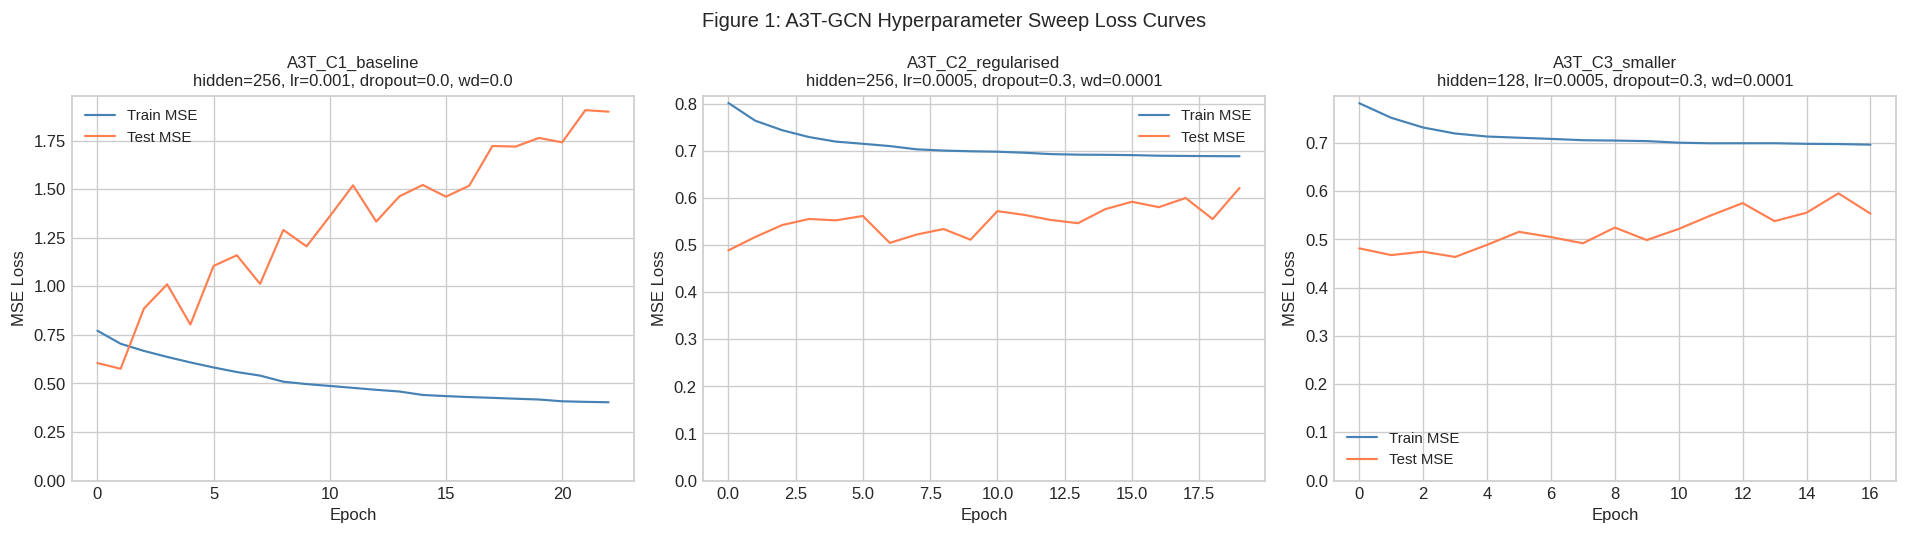

Saved fig1.


In [ ]:
# Figure 1: Sweep loss curves - all three A3T-GCN configurations
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, res) in zip(axes, sweep_results.items()):
    ax.plot(res['train_losses'], label='Train MSE', color='steelblue', linewidth=1.3)
    ax.plot(res['test_losses'],  label='Test MSE',  color='coral',     linewidth=1.3)
    cfg = res['config']
    ax.set_title(f"{name}\nhidden={cfg['hidden']}, lr={cfg['lr']}, "
                 f"dropout={cfg['dropout']}, wd={cfg['wd']}", fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
plt.suptitle('Figure 1: A3T-GCN Hyperparameter Sweep Loss Curves', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_sweep_losses.png', bbox_inches='tight')
plt.show()
print('Saved fig1.')

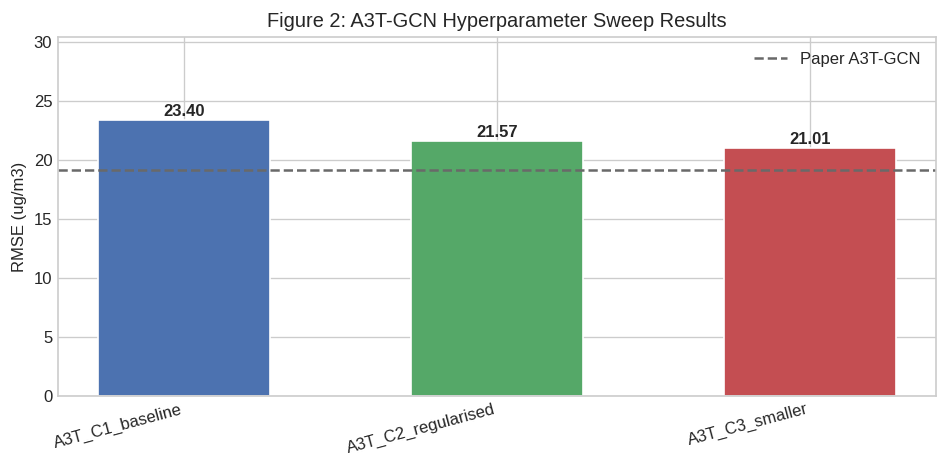

Saved fig2.


In [ ]:
# Figure 2: Sweep RMSE bar chart
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(sweep_results.keys())
rmses  = [sweep_results[n]['metrics']['RMSE'] for n in names]
colors = ['#4C72B0', '#55A868', '#C44E52']
bars   = ax.bar(names, rmses, color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(19.14, color='dimgray', linestyle='--', linewidth=1.5, label='Paper A3T-GCN')
ax.set_ylabel('RMSE (ug/m3)')
ax.set_title('Figure 2: A3T-GCN Hyperparameter Sweep Results')
ax.set_ylim(0, max(rmses) * 1.3)
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_sweep_rmse.png', bbox_inches='tight')
plt.show()
print('Saved fig2.')

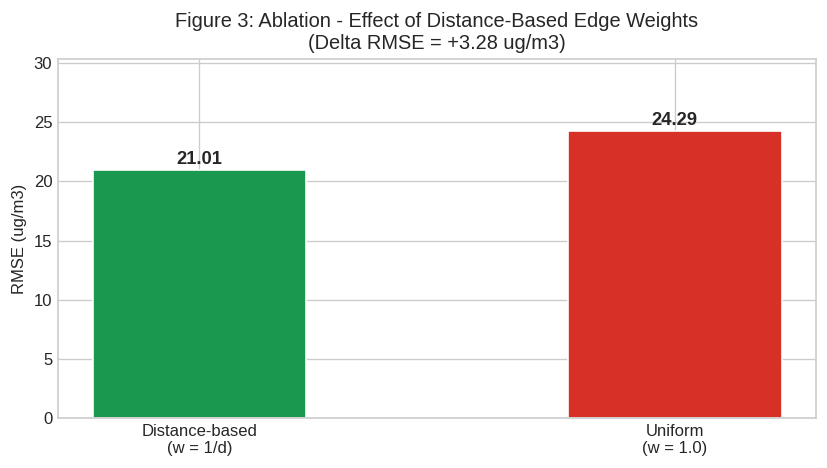

Saved fig3.


In [ ]:
# Figure 3: Ablation - distance vs uniform edge weights
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Distance-based\n(w = 1/d)', 'Uniform\n(w = 1.0)']
vals   = [best_a3t['metrics']['RMSE'], metrics_uniform['RMSE']]
colors = ['#1a9850', '#d73027']
bars   = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE (ug/m3)')
ax.set_title(f'Figure 3: Ablation - Effect of Distance-Based Edge Weights\n'
             f'(Delta RMSE = {ablation_delta_rmse:+.2f} ug/m3)')
ax.set_ylim(0, max(vals) * 1.25)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_ablation.png', bbox_inches='tight')
plt.show()
print('Saved fig3.')

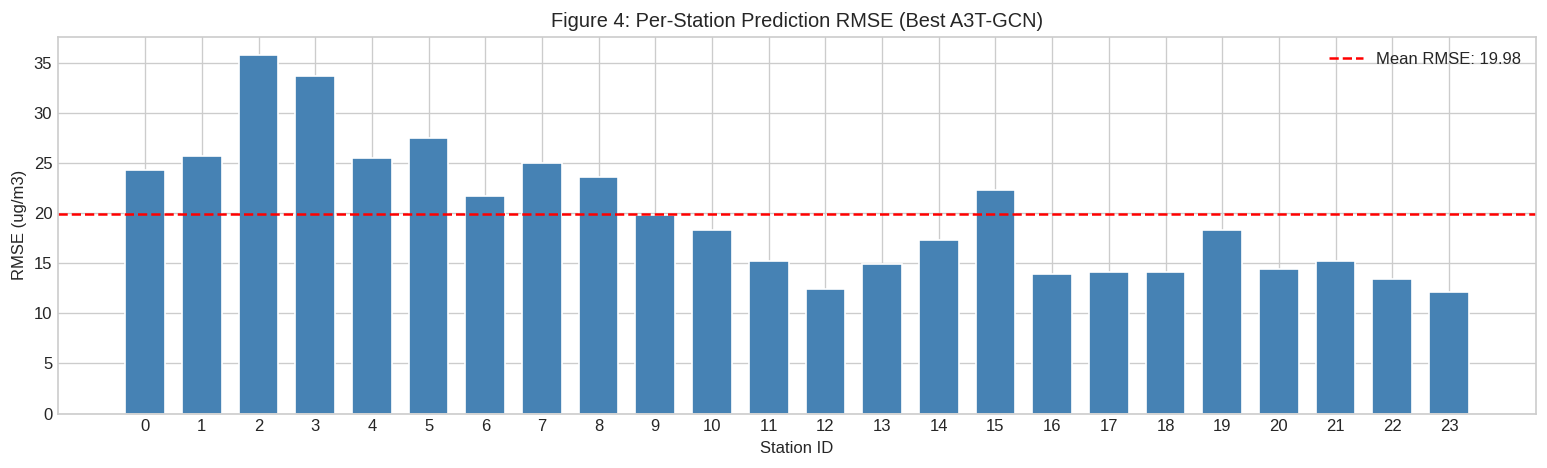

Saved fig4.


In [ ]:
# Figure 4: Per-station RMSE bar chart
fig, ax = plt.subplots(figsize=(13, 4))
df_sorted = df_station.sort_values('station').reset_index(drop=True)
bars = ax.bar(df_sorted['station'].astype(str), df_sorted['rmse'],
              color='steelblue', edgecolor='white', width=0.7)
ax.axhline(df_sorted['rmse'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f"Mean RMSE: {df_sorted['rmse'].mean():.2f}")
ax.set_xlabel('Station ID')
ax.set_ylabel('RMSE (ug/m3)')
ax.set_title('Figure 4: Per-Station Prediction RMSE (Best A3T-GCN)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig4_per_station_rmse.png', bbox_inches='tight')
plt.show()
print('Saved fig4.')

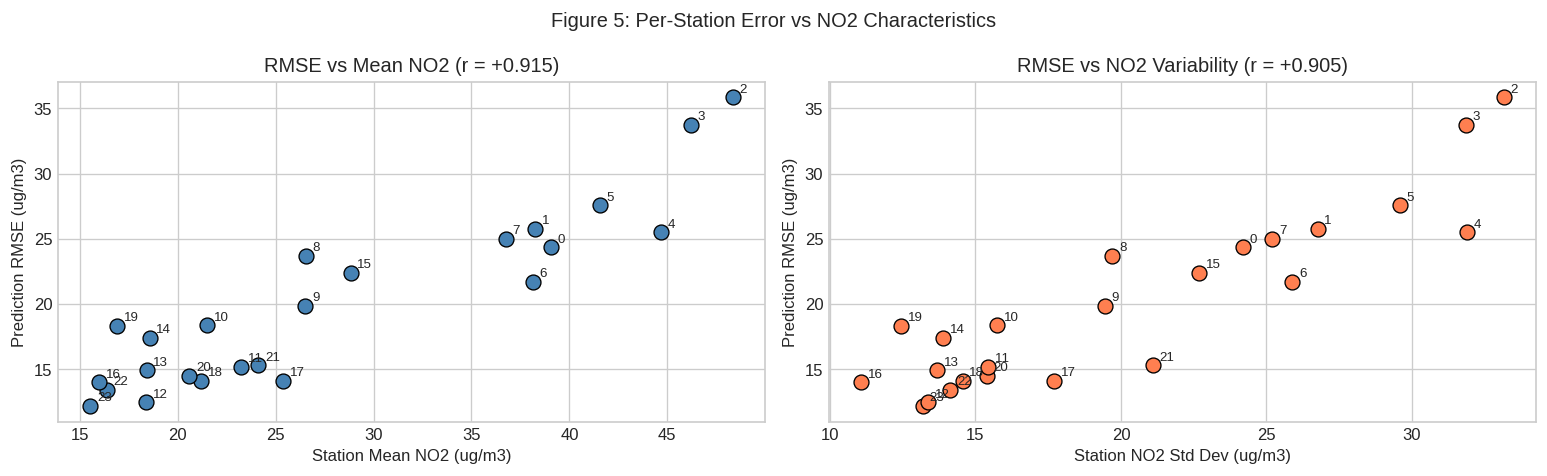

Saved fig5.


In [ ]:
# Figure 5: Per-station RMSE vs NO2 variability scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df_station['mean_no2'], df_station['rmse'],
                s=80, c='steelblue', edgecolors='black', linewidth=0.8)
for _, row in df_station.iterrows():
    axes[0].annotate(str(int(row['station'])),
                     (row['mean_no2'], row['rmse']),
                     fontsize=8, xytext=(4, 3), textcoords='offset points')
axes[0].set_xlabel('Station Mean NO2 (ug/m3)')
axes[0].set_ylabel('Prediction RMSE (ug/m3)')
axes[0].set_title(f'RMSE vs Mean NO2 (r = {r_mean_rmse:+.3f})')

axes[1].scatter(df_station['std_no2'], df_station['rmse'],
                s=80, c='coral', edgecolors='black', linewidth=0.8)
for _, row in df_station.iterrows():
    axes[1].annotate(str(int(row['station'])),
                     (row['std_no2'], row['rmse']),
                     fontsize=8, xytext=(4, 3), textcoords='offset points')
axes[1].set_xlabel('Station NO2 Std Dev (ug/m3)')
axes[1].set_ylabel('Prediction RMSE (ug/m3)')
axes[1].set_title(f'RMSE vs NO2 Variability (r = {r_std_rmse:+.3f})')

plt.suptitle('Figure 5: Per-Station Error vs NO2 Characteristics', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig5_station_scatter.png', bbox_inches='tight')
plt.show()
print('Saved fig5.')

## 11. Final Comparison Table

Comparison of all models including the best A3T-GCN from this notebook.
GRU, LSTM, and T-GCN metrics are from PR2 (no retraining needed).

In [ ]:
# PR2 baseline metrics (carried over so we can compare without retraining)
PR2 = {
    'GRU':         {'RMSE': 21.16, 'MAE': 15.11, 'R': 0.54},
    'LSTM':        {'RMSE': 21.44, 'MAE': 15.29, 'R': 0.52},
    'T-GCN':       {'RMSE': 21.56, 'MAE': 15.99, 'R': 0.41},
    'A3T-GCN (PR2)':{'RMSE': 24.10, 'MAE': 17.77, 'R': 0.41},
}
PAPER = {
    'GRU':         {'RMSE': 22.29, 'MAE': 16.97, 'R': 0.56},
    'LSTM':        {'RMSE': 22.33, 'MAE': 16.70, 'R': 0.57},
    'T-GCN':       {'RMSE': 21.48, 'MAE': 16.24, 'R': 0.49},
    'A3T-GCN (PR2)':{'RMSE': 19.14, 'MAE': 15.33, 'R': 0.59},
}

final_a3t = best_a3t['metrics']
PR2['A3T-GCN (Final)'] = final_a3t
PAPER['A3T-GCN (Final)'] = {'RMSE': 19.14, 'MAE': 15.33, 'R': 0.59}

print('=' * 78)
print(f'{"Model":<20} {"RMSE":>8} {"Ref":>8} {"MAE":>8} {"Ref":>8} {"R":>8} {"Ref":>8}')
print('-' * 78)
for name, m in PR2.items():
    p = PAPER[name]
    print(f'{name:<20} {m["RMSE"]:>8.4f} {p["RMSE"]:>8.2f} '
          f'{m["MAE"]:>8.4f} {p["MAE"]:>8.2f} '
          f'{m["R"]:>8.4f} {p["R"]:>8.2f}')
print('=' * 78)

rows = []
for name, m in PR2.items():
    p = PAPER[name]
    rows.append({'Model': name,
                 'RMSE_ours': m['RMSE'], 'RMSE_paper': p['RMSE'],
                 'MAE_ours':  m['MAE'],  'MAE_paper':  p['MAE'],
                 'R_ours':    m['R'],    'R_paper':    p['R']})
pd.DataFrame(rows).to_csv(f'{RESULTS_DIR}/final_metrics.csv', index=False)
print(f'Saved to {RESULTS_DIR}/final_metrics.csv')

Model                    RMSE      Ref      MAE      Ref        R      Ref
------------------------------------------------------------------------------
GRU                   21.1600    22.29  15.1100    16.97   0.5400     0.56
LSTM                  21.4400    22.33  15.2900    16.70   0.5200     0.57
T-GCN                 21.5600    21.48  15.9900    16.24   0.4100     0.49
A3T-GCN (PR2)         24.1000    19.14  17.7700    15.33   0.4100     0.59
A3T-GCN (Final)       21.0081    19.14  15.0597    15.33   0.4693     0.59
Saved to /content/drive/MyDrive/cmp712_2026_project/final_results/final_metrics.csv


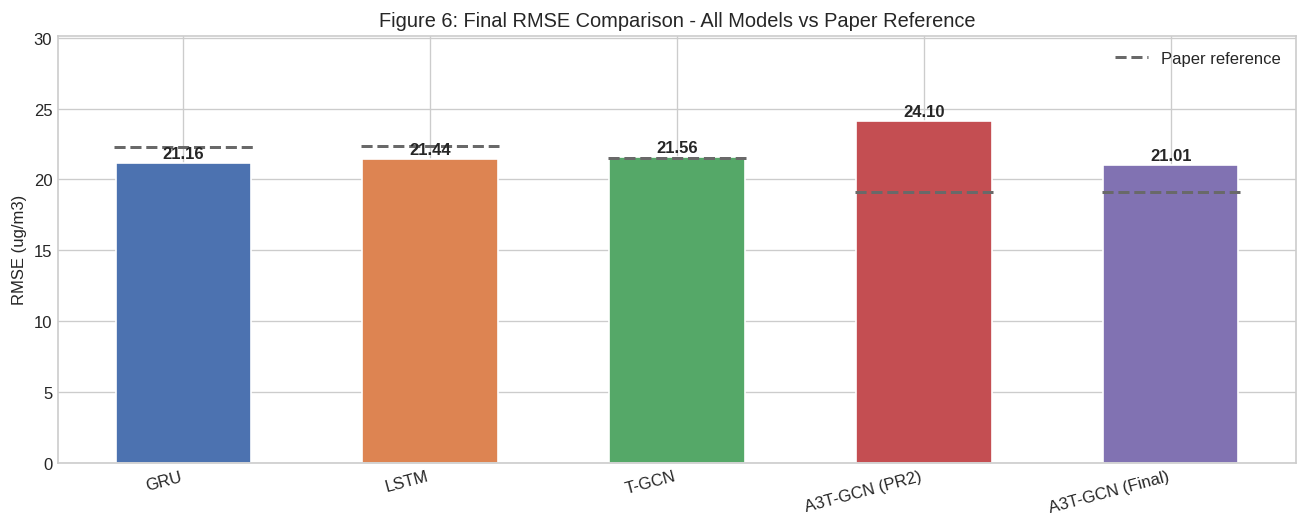

Saved fig6.


In [ ]:
# Figure 6: Final comparison bar chart - all 4 models, ours vs paper
model_names = ['GRU', 'LSTM', 'T-GCN', 'A3T-GCN (PR2)', 'A3T-GCN (Final)']
rmse_ours   = [PR2[n]['RMSE']   for n in model_names]
rmse_paper  = [PAPER[n]['RMSE'] for n in model_names]
colors      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(model_names, rmse_ours, color=colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, rmse_ours):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for i, pval in enumerate(rmse_paper):
    ax.hlines(pval, i - 0.28, i + 0.28, colors='dimgray',
              linestyles='--', linewidth=1.8,
              label='Paper reference' if i == 0 else '')
ax.set_ylabel('RMSE (ug/m3)')
ax.set_title('Figure 6: Final RMSE Comparison - All Models vs Paper Reference')
ax.legend()
ax.set_ylim(0, max(rmse_ours) * 1.25)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig6_final_comparison.png', bbox_inches='tight')
plt.show()
print('Saved fig6.')

## 12. Final Summary

In [ ]:
summary = {
    'gpu':                 torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
    'best_a3t_config':     best_config_name,
    'best_a3t_metrics':    best_a3t['metrics'],
    'pr2_a3t_metrics':     PR2['A3T-GCN (PR2)'],
    'improvement_vs_pr2':  {
        'rmse_reduction': PR2['A3T-GCN (PR2)']['RMSE'] - best_a3t['metrics']['RMSE'],
        'mae_reduction':  PR2['A3T-GCN (PR2)']['MAE']  - best_a3t['metrics']['MAE'],
        'r_improvement':  best_a3t['metrics']['R']     - PR2['A3T-GCN (PR2)']['R'],
    },
    'gap_to_paper':        {
        'rmse': best_a3t['metrics']['RMSE'] - 19.14,
        'mae':  best_a3t['metrics']['MAE']  - 15.33,
        'r':    0.59 - best_a3t['metrics']['R'],
    },
    'ablation_uniform_rmse': metrics_uniform['RMSE'],
    'ablation_delta_rmse':   ablation_delta_rmse,
    'hardest_stations':    df_station.nlargest(3, 'rmse')['station'].tolist(),
    'easiest_stations':    df_station.nsmallest(3, 'rmse')['station'].tolist(),
    'station_mean_rmse_corr': r_mean_rmse,
    'station_std_rmse_corr':  r_std_rmse,
}

with open(f'{RESULTS_DIR}/final_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('=' * 62)
print('  FINAL REPORT - SUMMARY')
print('=' * 62)
print(f'  Platform           : Google Colab ({summary["gpu"]})')
print(f'  Best A3T-GCN config: {best_config_name}')
print(f'  Best A3T-GCN RMSE  : {best_a3t["metrics"]["RMSE"]:.4f} ug/m3')
print(f'  Best A3T-GCN MAE   : {best_a3t["metrics"]["MAE"]:.4f} ug/m3')
print(f'  Best A3T-GCN R     : {best_a3t["metrics"]["R"]:.4f}')
print(f'  RMSE improvement vs PR2: {summary["improvement_vs_pr2"]["rmse_reduction"]:+.4f}')
print()
print(f'  Ablation:')
print(f'    Distance-weighted RMSE : {best_a3t["metrics"]["RMSE"]:.4f}')
print(f'    Uniform-weighted RMSE  : {metrics_uniform["RMSE"]:.4f}')
print(f'    Delta                  : {ablation_delta_rmse:+.4f} ug/m3')
print()
print(f'  Per-station analysis:')
print(f'    Hardest stations: {summary["hardest_stations"]}')
print(f'    Easiest stations: {summary["easiest_stations"]}')
print(f'    Corr(mean NO2, RMSE) = {r_mean_rmse:+.3f}')
print(f'    Corr(std  NO2, RMSE) = {r_std_rmse:+.3f}')
print('=' * 62)
print(f'Results saved to: {RESULTS_DIR}')

  FINAL REPORT - SUMMARY
  Platform           : Google Colab (Tesla T4)
  Best A3T-GCN config: A3T_C3_smaller
  Best A3T-GCN RMSE  : 21.0081 ug/m3
  Best A3T-GCN MAE   : 15.0597 ug/m3
  Best A3T-GCN R     : 0.4693
  RMSE improvement vs PR2: +3.0919

  Ablation:
    Distance-weighted RMSE : 21.0081
    Uniform-weighted RMSE  : 24.2907
    Delta                  : +3.2826 ug/m3

  Per-station analysis:
    Hardest stations: [2, 3, 5]
    Easiest stations: [23, 12, 22]
    Corr(mean NO2, RMSE) = +0.915
    Corr(std  NO2, RMSE) = +0.905
Results saved to: /content/drive/MyDrive/cmp712_2026_project/final_results
